In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,accuracy_score,f1_score,recall_score,classification_report,confusion_matrix
from sklearn.metrics import  precision_recall_curve, auc, average_precision_score,roc_auc_score,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [3]:
# Load the breast cancer dataset for this problems
X , y = load_breast_cancer(return_X_y=True)

In [4]:
# Now we will split the data into training and testing set 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.3 , random_state = 42 )

In [5]:
# Now we will use Logistic Regression and Decision Tree Classifier to do Classification Metric Analysis
# Basically we all this to determine which algorithm is the best performing . 

# Loading and Instantiating models
log = LogisticRegression(max_iter=5000)
clf = DecisionTreeClassifier()
# We are using this as both are models to do classification type problems

In [6]:
# Fit both the models 
log.fit(X_train,y_train)
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [7]:
# Store predictions from both the models.
y_pred_lor = log.predict(X_test)
y_pred_clf = clf.predict(X_test)

In [8]:
# Now lets compare both the models scores
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Accuracy score :  {accuracy_score(y_test,y_pred_lor)}  {accuracy_score(y_test,y_pred_clf)}')
print(f' Precision score : {precision_score(y_test,y_pred_lor)}  {precision_score(y_test,y_pred_clf)}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor)}  {recall_score(y_test,y_pred_clf)}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor)}  {f1_score(y_test,y_pred_clf)}')

 	 	   Scores for LR       Scores for CLF 
 Accuracy score :  0.9766081871345029  0.935672514619883
 Precision score : 0.9814814814814815  0.9619047619047619
 Recall score :    0.9814814814814815  0.9351851851851852
 F1 score :        0.9814814814814815  0.9483568075117371


In [9]:
# Compring the confusion matrix and the TP,TN,FP,FN values
#   00 = True Positives - The actual and predicted values for correct data from models matched
#   11 = True Negatives - The actual and predicted values for incorrect data from models matched
#   01 = False Negatives - The actual labels were not predicted by the model (Did not predict something which was correct,need to be predicted)
#   10 = False Positive - The predictions made by model were incorrect (labelled incorrectly )
conf1 = pd.DataFrame(confusion_matrix(y_test,y_pred_lor))
conf2 = pd.DataFrame(confusion_matrix(y_test,y_pred_clf))

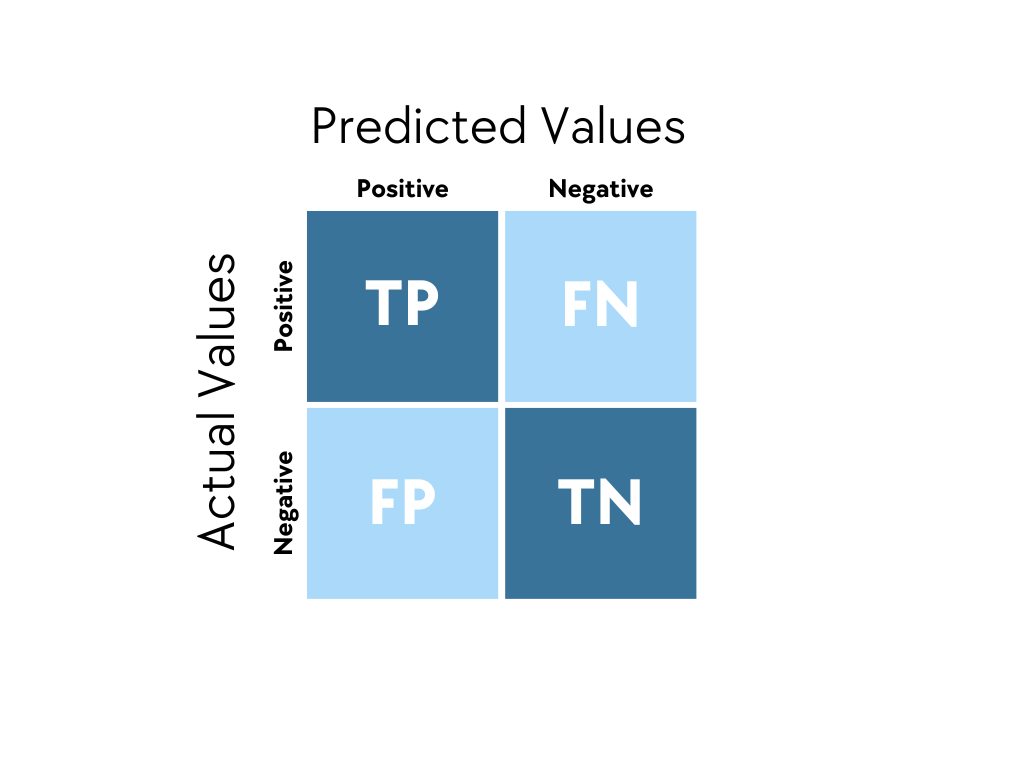

In [10]:
conf1 

,0,1
0,61,2
1,2,106


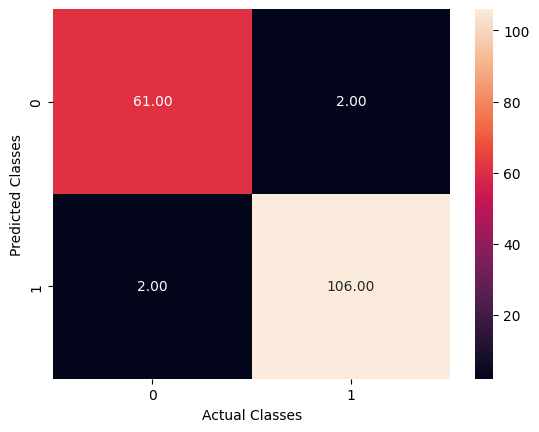

In [11]:
sns.heatmap(data = conf1 , annot = True , fmt = '.2f') 
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [12]:
conf2

,0,1
0,59,4
1,7,101


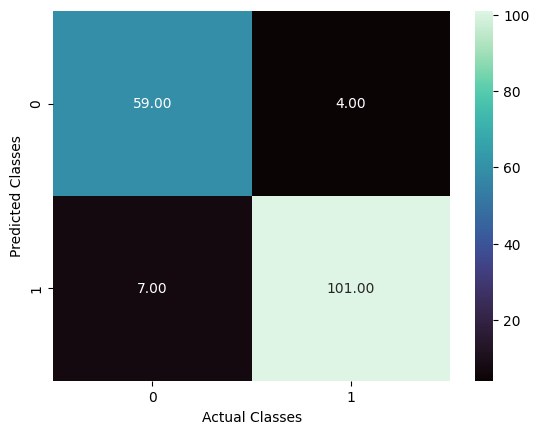

In [13]:
sns.heatmap(data = conf2 , annot = True , fmt = '.2f' , cmap = 'mako') 
plt.xlabel("Actual Classes")
plt.ylabel("Predicted Classes")
plt.show()

In [14]:
# Note this same can be done on multiple columns for multiple labels 
# There we will calculate all the scores for one label by label

In [15]:
# Also to calculate scores for each there are two methods :
# First by using weights
# Second by using average which is the default 

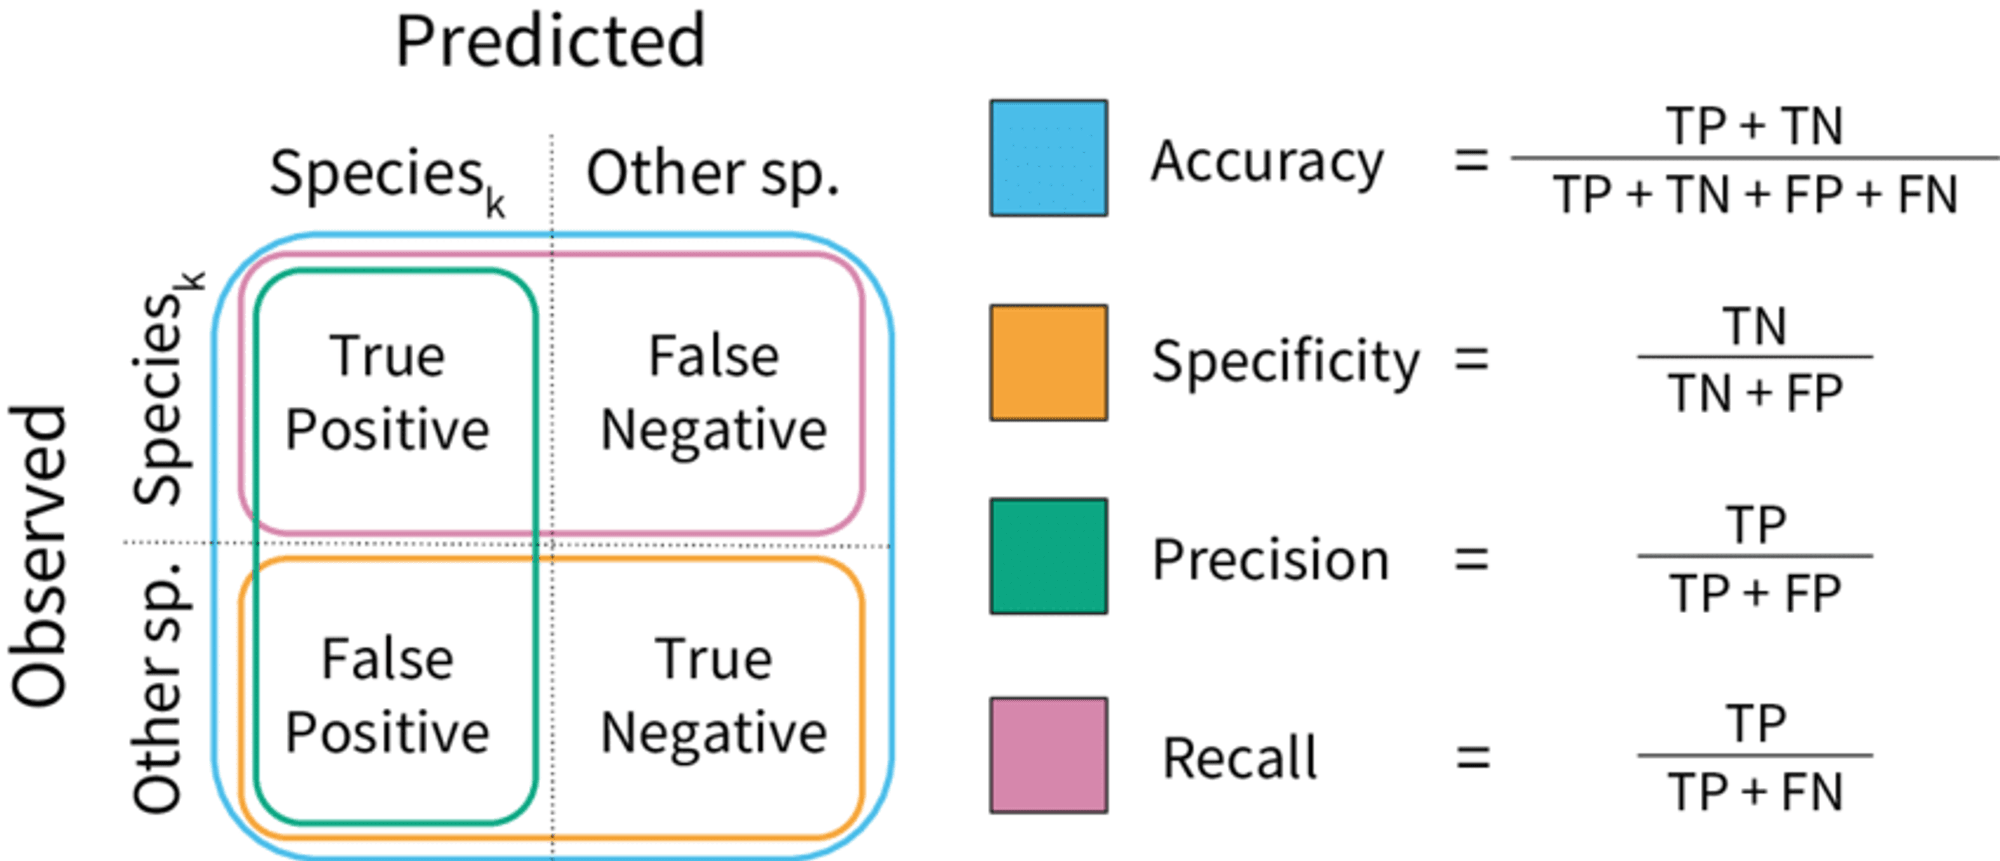

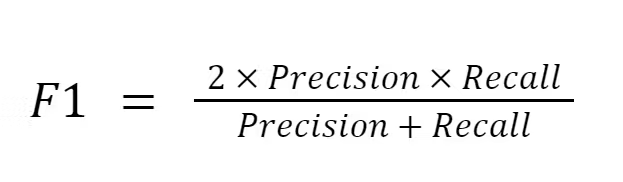

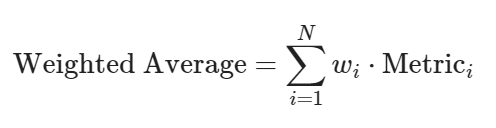

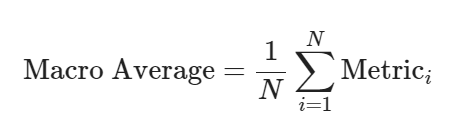

In [16]:
# This is when we do average is None so we get the score for each 
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Precision score : {precision_score(y_test,y_pred_lor,average=None)}  {precision_score(y_test,y_pred_clf,average=None)}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor,average=None)}  {recall_score(y_test,y_pred_clf,average=None)}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor,average=None)}  {f1_score(y_test,y_pred_clf,average=None)}')
# As you can see we had two labels so 2 columns 
# Same applicable for multiple columns (Also confusion matrix)

 	 	   Scores for LR       Scores for CLF 
 Precision score : [0.96825397 0.98148148]  [0.89393939 0.96190476]
 Recall score :    [0.96825397 0.98148148]  [0.93650794 0.93518519]
 F1 score :        [0.96825397 0.98148148]  [0.91472868 0.94835681]


In [17]:
# This is when we do average is 'macro' / weighted average so we get the score for each 
print(f' \t \t   Scores for LR       Scores for CLF ')
print(f' Precision score : {precision_score(y_test,y_pred_lor,average='macro')}  {precision_score(y_test,y_pred_clf,average='macro')}')
print(f' Recall score :    {recall_score(y_test,y_pred_lor,average='macro')}  {recall_score(y_test,y_pred_clf,average='macro')}')
print(f' F1 score :        {f1_score(y_test,y_pred_lor,average='macro')}  {f1_score(y_test,y_pred_clf,average='macro')}')

 	 	   Scores for LR       Scores for CLF 
 Precision score : 0.9748677248677249  0.9279220779220779
 Recall score :    0.9748677248677249  0.9358465608465609
 F1 score :        0.9748677248677249  0.9315427448411399


In [18]:
print(classification_report(y_test,y_pred_lor))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        63
           1       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



In [19]:
print(classification_report(y_test,y_pred_clf))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91        63
           1       0.96      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.93       171
weighted avg       0.94      0.94      0.94       171



In [20]:
# Now we will talk about some other advanced metrics 

### **📈 ROC AUC Score: Measuring Diagnostic Ability**

The **ROC AUC Score** (Receiver Operating Characteristic - Area Under the Curve) is the gold standard for evaluating classification models in medical diagnostics like **Breast Cancer** detection.

#### **1. What is the ROC Curve?**
The ROC curve plots the trade-off between:
*   **True Positive Rate (Sensitivity):** Ability to catch all actual cancer cases.
*   **False Positive Rate (1 - Specificity):** Probability of a healthy patient being wrongly flagged.

#### **2. Understanding the AUC (Area Under Curve)**
The AUC value (ranging from **0.5 to 1.0**) summarizes the model's performance across all classification thresholds. Unlike **Accuracy**, it remains reliable even if the dataset is **imbalanced**.

| AUC Score | Quality | Interpretation |
| :--- | :--- | :--- |
| **0.90 – 1.0** | **Excellent** | Perfect or near-perfect diagnostic separation. |
| **0.80 – 0.90** | **Good** | High clinical utility; low error rates. |
| **0.70 – 0.80** | **Fair** | Moderate predictive power; needs improvement. |
| **0.50** | **Failure** | No better than flipping a coin. |


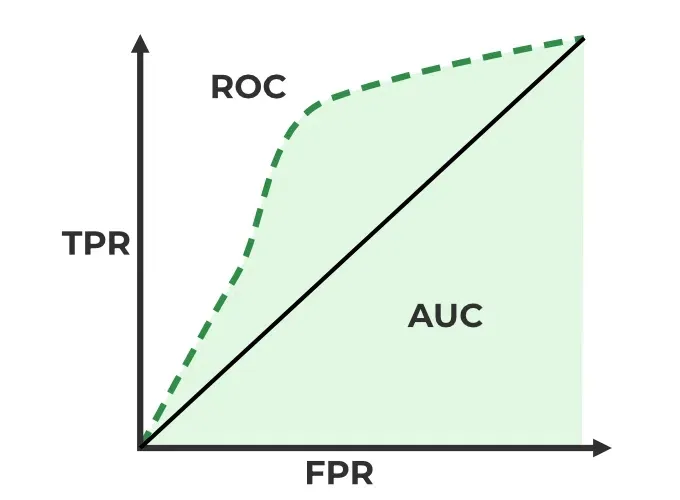

In [21]:
roc_auc_score(y_test,log.predict_proba(X_test)[:,1])

0.9976484420928865

In [22]:
roc_auc_score(y_test,clf.predict_proba(X_test)[:,1])

0.9358465608465608

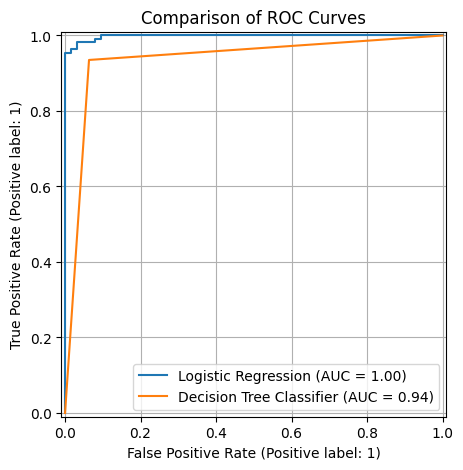

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(9, 5))

# 2. Plot Model 1 (e.g., Logistic Regression)
RocCurveDisplay.from_estimator(log, X_test, y_test, ax=ax, name='Logistic Regression')

# 3. Plot Model 2 (e.g., Random Forest)
RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax, name='Decision Tree Classifier')

# 4. Final touches
plt.title('Comparison of ROC Curves')
plt.grid(True)
plt.show()


In [24]:
# Now calculating cohen kappa score 

### **$\kappa$ Cohen’s Kappa Score: Adjusting for Chance**

The **Cohen’s Kappa Score** is a robust metric used to evaluate the reliability of a classification model. Unlike standard **Accuracy**, it accounts for the possibility of a model getting a correct answer by **random chance**.

#### **1. Why Accuracy can be Misleading**
In the **Breast Cancer dataset**, if 63% of patients are "Benign," a model that blindly predicts "Benign" for everyone will still achieve **63% accuracy**. However, that model has **zero** diagnostic value. 

#### **2. How Kappa Works**
Kappa subtracts the "luck" from the accuracy to find the true predictive power:
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$
*   **$p_o$ (Observed Agreement):** The actual accuracy of your model.
*   **$p_e$ (Expected Agreement):** The probability of the model and the actual labels agreeing by pure luck.

#### **3. Interpreting the Result**
The score typically ranges from **0 to 1**. For medical diagnostics, we follow the [Landis & Koch scale](https://www.jstor.org) used by [Scikit-Learn](https://scikit-learn.org):

| Kappa Score | Strength of Agreement |
| :--- | :--- |
| **0.81 – 1.00** | **Almost Perfect** — The model is highly reliable. |
| **0.61 – 0.80** | **Substantial** — Very strong predictive power. |
| **0.41 – 0.60** | **Moderate** — Average; the model makes notable errors. |
| **< 0.40** | **Poor / Fair** — The model is not suitable for clinical use. |


In [25]:
# Use the actual and predicted labels (not probabilities)
y_pred = log.predict(X_test)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Cohen’s Kappa Score: {kappa:.4f}")


Cohen’s Kappa Score: 0.9497


### **$\text{PR AUC}$ Precision-Recall AUC: The Truth-Teller for Imbalanced Data**

The **Precision-Recall Area Under the Curve (PR AUC)** is the gold-standard metric for evaluating models when one class is much rarer than the other—like **Customer Churn**. It focuses purely on the model's ability to handle the "Positive" (minority) class.

---

#### **1. Why ROC AUC can be Misleading**
In a churn dataset where only 10% of customers leave, a model can achieve a very high [ROC AUC](https://scikit-learn.org) simply by being good at identifying the 90% who stay. **PR AUC**, however, ignores the "True Negatives" (the people who stayed) and puts the spotlight entirely on how well you find and accurately predict the **Churners**.

#### **2. How PR AUC Works**
PR AUC calculates the area under the curve formed by plotting **Precision** against **Recall** for every possible probability threshold (from 0 to 1). 

*   **Precision ($P$):** $\frac{TP}{TP + FP}$ — "When I predict churn, how often am I right?"
*   **Recall ($R$):** $\frac{TP}{TP + FN}$ — "How many of the actual churners did I catch?"

The area is mathematically calculated using **Average Precision**:
$$\text{PR AUC} = \sum_{n} (R_n - R_{n-1}) P_n$$

#### **3. Interpreting the Result**
The score ranges from **0 to 1**. Unlike Accuracy or ROC, the "baseline" (worst case) isn't 0.5; it is equal to the **prevalence** of the positive class in your specific data.


| PR AUC Score | Performance Meaning |
| :--- | :--- |
| **0.90 – 1.00** | **Exemplary** — High precision and high recall; a near-perfect classifier. |
| **0.70 – 0.89** | **Strong** — Very reliable for business interventions and targeting. |
| **0.50 – 0.69** | **Decent** — Useful, but will either miss churners or create false alarms. |
| **Baseline ($\approx$ 0.10)** | **No Skill** — No better than a random guess based on class frequency. |

#### **4. Implementation in Scikit-Learn**
You can calculate this directly using [average_precision_score](https://scikit-learn.org) or the [auc](https://scikit-learn.org) function.

```python
from sklearn.metrics import average_precision_score
y_probs = model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, y_probs)
print(f"PR AUC Score: {pr_auc:.4f}")


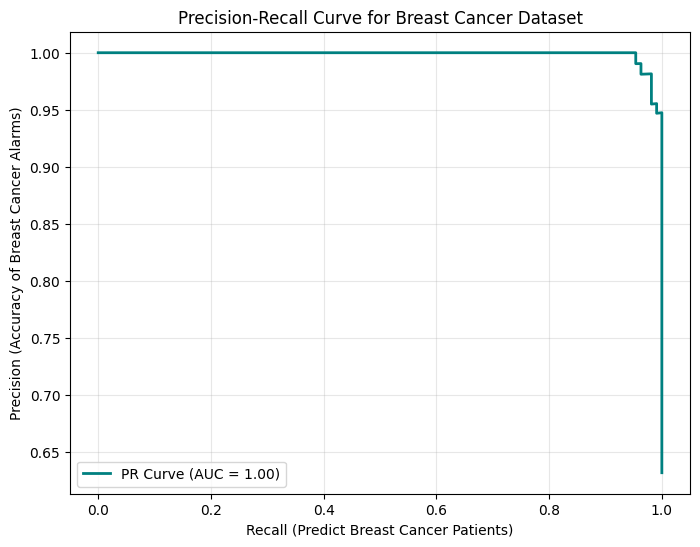

In [27]:
y_probs = log.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc_score = auc(recall, precision)
avg_precision = average_precision_score(y_test, y_probs)

# 4. Plot the Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc_score:.2f})', color='teal', lw=2)
plt.xlabel('Recall (Predict Breast Cancer Patients)')
plt.ylabel('Precision (Accuracy of Breast Cancer Alarms)')
plt.title('Precision-Recall Curve for Breast Cancer Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [28]:
# Below is the example classification metric example 

### **The "Hardcore" Classification Guide: Credit Card Fraud Detection**

In a world where **99.9%** of transactions are legitimate, standard metrics like **Accuracy** are useless. To build a production-grade fraud engine, we must dissect the model using a "Full-Stack" metric approach.

#### **The Scenario: 100,000 Transactions**
*   **Actual Fraud (Class 1):** 100 
*   **Actual Legit (Class 0):** 99,900

Our model produces the following **Confusion Matrix**:


| | Predicted: FRAUD | Predicted: LEGIT | Total |
| :--- | :--- | :--- | :--- |
| **Actual: FRAUD** | **80 (True Positive)** | 20 (False Negative) | 100 |
| **Actual: LEGIT** | 400 (False Positive) | **99,500 (True Negative)** | 99,900 |

---

#### **1. Accuracy: The "Participation Trophy"**
$$\text{Accuracy} = \frac{TP + TN}{\text{Total}} = \frac{80 + 99,500}{100,000} = \mathbf{99.58\%}$$
*   **The Trap:** If we simply predicted "Legit" for every single person, we would get **99.90% accuracy** but **0% fraud detection**. 
*   **The Verdict:** In imbalanced data, accuracy is a "liar's metric."

#### **2. Precision: The "Customer Experience" Score**
$$\text{Precision} = \frac{TP}{TP + FP} = \frac{80}{80 + 400} = \mathbf{16.6\%}$$
*   **Interpretation:** "When the model flags a transaction as Fraud, it is only right 16.6% of the time."
*   **Business Impact:** 83.4% of flagged customers (False Positives) will have their cards declined at the checkout counter. Low precision kills user trust.

#### **3. Recall (Sensitivity): The "Safety" Score**
$$\text{Recall} = \frac{TP}{TP + FN} = \frac{80}{80 + 20} = \mathbf{80.0\%}$$
*   **Interpretation:** "The model successfully caught 80% of the total fraud volume."
*   **Business Impact:** 20% of thieves (False Negatives) got away with the money. In Fraud/Medicine, **Recall is the priority.**

#### **4. Specificity: The "Negative Reliability"**
$$\text{Specificity} = \frac{TN}{TN + FP} = \frac{99,500}{99,500 + 400} = \mathbf{99.6\%}$$
*   **Interpretation:** "How good is the model at identifying 'Good' customers?" 
*   **Importance:** High specificity ensures that the "Legit" pool isn't being accidentally harassed.

#### **5. F1-Score: The "Harmonic Compromise"**
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \mathbf{27.5\%}$$
*   **Interpretation:** The F1-Score is the "truth-teller" here. Despite the 99.5% accuracy, the F1-score of 27.5% reveals the model is struggling to balance the massive False Positive count against the Fraud detection.

#### **6. $\kappa$ Cohen’s Kappa: Adjusting for Chance**
$$\kappa = \frac{p_o - p_e}{1 - p_e}$$
*   **Interpretation:** This is the **"Anti-Luck"** metric. It calculates how much better the model is than a model that just **guesses based on class frequency**.
*   **The Verdict:** A Kappa near 0 means the model is no better than a random guesser. Our model would likely have a moderate Kappa because it successfully beat the 99.9% baseline.

#### **7. MCC (Matthews Correlation Coefficient): The "Ultimate" Score**
$$MCC = \frac{TP \times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$
*   **Why it's better:** Unlike F1 or Accuracy, MCC uses all four quadrants of the confusion matrix. 
*   **Scale:** Range is -1 to +1. **+1** is perfect, **0** is random, **-1** is total disagreement.
*   **Verdict:** If your MCC is high, your model is truly robust on both classes.

---

### **Which Metric Wins for your App?**



| Use Case | Priority Metric | The "Why" |
| :--- | :--- | :--- |
| **Credit Card Fraud** | **Recall / PR AUC** | Missing one $50k fraud is worse than blocking a few cards. |
| **Spam Filters** | **Precision** | A user should never miss a job offer because it went to Spam. |
| **Customer Churn** | **F1-Score** | Balance catching leavers vs. wasting discount budgets. |
| **Balanced Classes** | **Accuracy / ROC AUC** | When data is 50/50, standard metrics work fine. |

---

### **Implementation Snippet**

```python
from sklearn.metrics import classification_report, cohen_kappa_score, matthews_corrcoef

# Generating the comprehensive report
print(classification_report(y_test, y_pred))

# Advanced Reliability Metrics
print(f"Cohen's Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")
print(f"Matthews CorrCoef: {matthews_corrcoef(y_test, y_pred):.4f}")
